In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.plotting_functions import *

In [23]:
wanted_parameters = ["stat_test_2"]
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

stat_test_2
[WindowsPath('C:/Users/aSuryawanshi/Documents/Codes/Dual_Pathway_RL_songbird/Stat_test/results/param_stat_test_2')]


In [24]:
terminal_performance = {}
motor_displacement = {}
reward_displacement = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)
    if param == "N_DISTRACTORS":
        print(f"Processing {folder.name} with special handling for N_DISTRACTORS")
        nos_peaks_path = folder / "nos_peaks.npy"
        if nos_peaks_path.exists():
            nos_peaks = np.load(nos_peaks_path)
            print(f"Loaded nos_peaks for {folder.name}")
        else:
            print(f"⚠️ Missing nos_peaks.npy for {folder.name}")

    perf_path = folder / "terminal_performance.npy"
    motor_displacement_path = folder / "motor_displacement.npy"
    reward_displacement_path = folder / "reward_displacement.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)
    motor_displacement[param] = np.load(motor_displacement_path) if motor_displacement_path.exists() else None
    reward_displacement[param] = np.load(reward_displacement_path) if reward_displacement_path.exists() else None

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


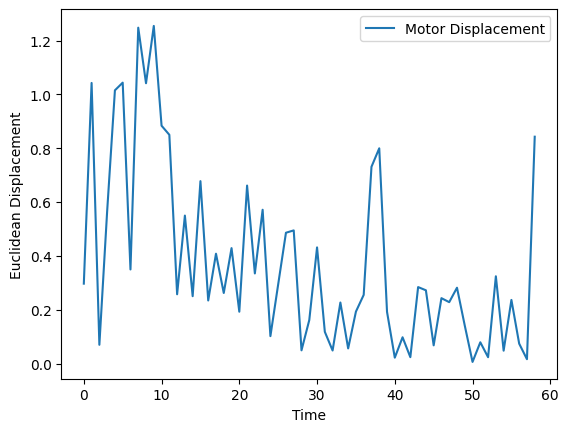

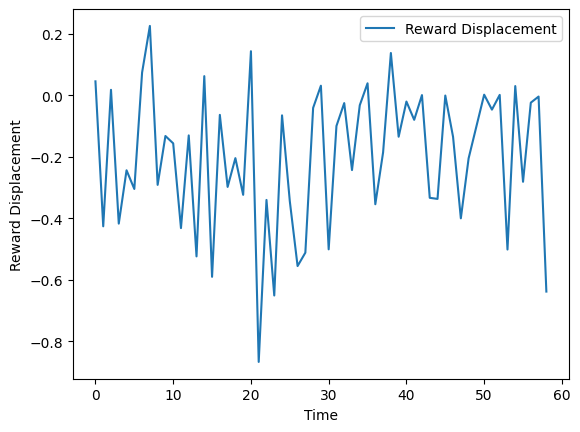

In [25]:
plt.plot(np.sqrt(motor_displacement['stat_test_2'][0, :, 0, 0]**2 + motor_displacement['stat_test_2'][0, :, 0, 1]**2), label='Motor Displacement')
plt.xlabel("Time")
plt.ylabel("Euclidean Displacement")
# plt.title(f"Motor Displacement for {average_over_n_days} days")
plt.legend()
plt.show()

plt.plot(reward_displacement['stat_test_2'][0, :, 0], label='Reward Displacement')
plt.xlabel("Time")
plt.ylabel("Reward Displacement")
# plt.title(f"Reward Displacement for {average_over_n_days} days")
plt.legend()
plt.show()

(100,)
Pearson correlation: -0.2050, p-value: 0.0408


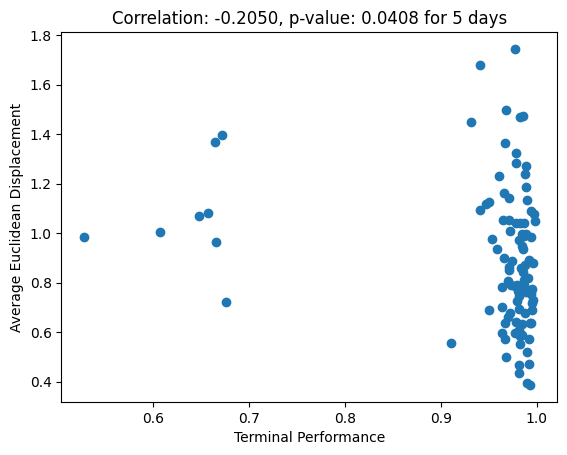

Pearson correlation: -0.1384, p-value: 0.1697


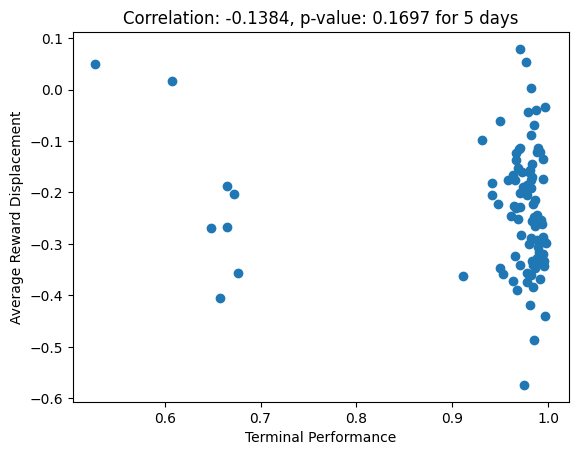

In [26]:
average_over_n_days = 5
eucledian_disp = np.mean(np.sqrt(motor_displacement['stat_test_2'][:,:average_over_n_days,0,0]**2 + motor_displacement['stat_test_2'][:,:average_over_n_days,0,1]**2), axis = 1)

reward_disp = np.mean(reward_displacement['stat_test_2'][:,:average_over_n_days,0], axis = 1)
print(reward_disp.shape)
# pearson correlation between terminal performance and eucledian displacement
from scipy.stats import pearsonr
corr, p_value = pearsonr(terminal_performance['stat_test_2'], eucledian_disp)
print(f"Pearson correlation: {corr:.4f}, p-value: {p_value:.4f}")
plt.scatter(terminal_performance['stat_test_2'], eucledian_disp)
plt.xlabel("Terminal Performance")
plt.ylabel("Average Euclidean Displacement")
plt.title(f"Correlation: {corr:.4f}, p-value: {p_value:.4f} for {average_over_n_days} days")
plt.show()

# pearson correlation between terminal performance and reward displacement
corr, p_value = pearsonr(terminal_performance['stat_test_2'], reward_disp)
print(f"Pearson correlation: {corr:.4f}, p-value: {p_value:.4f}")
plt.scatter(terminal_performance['stat_test_2'], reward_disp)
plt.xlabel("Terminal Performance")
plt.ylabel("Average Reward Displacement")
plt.title(f"Correlation: {corr:.4f}, p-value: {p_value:.4f} for {average_over_n_days} days")
plt.show()